#📌 Extracão

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
url= "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"
df = pd.read_json(url)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformação

Dicionário de dados

customerID: número de identificação único de cada clienTE

Churn: se o cliente deixou ou não a empresa

gender: gênero (masculino e feminino)

SeniorCitizen: informação sobre um cliente ter ou não idade igual ou maior que 65 anos

Partner: se o cliente possui ou não um parceiro ou parceira

Dependents: se o cliente possui ou não dependentes

tenure: meses de contrato do cliente

PhoneService: assinatura de serviço telefônico

MultipleLines: assisnatura de mais de uma linha de telefone

InternetService: assinatura de um provedor internet

OnlineSecurity: assinatura adicional de segurança online

OnlineBackup: assinatura adicional de backup online

DeviceProtection: assinatura adicional de proteção no dispositivo

TechSupport: assinatura adicional de suporte técnico, menos tempo de espera

StreamingTV: assinatura de TV a cabo

StreamingMovies: assinatura de streaming de filmes

Contract: tipo de contrato

PaperlessBilling: se o cliente prefere receber online a fatura

PaymentMethod: forma de pagamento

Charges.Monthly: total de todos os serviços do cliente por mês

Charges.Total: total gasto pelo cliente

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [ ]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [ ]:
print(df.columns)

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')


In [ ]:
dfaux = df["customer"].apply(pd.Series)
df = pd.concat([df.drop("customer", axis=1), dfaux], axis=1)

In [ ]:
dfaux = df["phone"].apply(pd.Series)
df = pd.concat([df.drop("phone", axis=1), dfaux], axis=1)

In [ ]:
dfaux = df["internet"].apply(pd.Series)
df = pd.concat([df.drop("internet", axis=1), dfaux], axis=1)

In [ ]:
dfaux = df["account"].apply(pd.Series)
df = pd.concat([df.drop("account", axis=1), dfaux], axis=1)

In [ ]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,"{'Monthly': 65.6, 'Total': '593.3'}"
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,"{'Monthly': 59.9, 'Total': '542.4'}"
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,"{'Monthly': 73.9, 'Total': '280.85'}"
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,"{'Monthly': 98.0, 'Total': '1237.85'}"
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,"{'Monthly': 83.9, 'Total': '267.4'}"


In [ ]:
dfaux = df["Charges"].apply(pd.Series)
df = pd.concat([df.drop("Charges", axis=1), dfaux], axis=1)

In [ ]:
for col in df.columns:
    print(col, pd.unique(df[col]))

customerID ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn ['No' 'Yes' '']
gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['Yes' 'No']
tenure [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
PhoneService ['Yes' 'No']
MultipleLines ['No' 'Yes' 'No phone service']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['Yes' 'No' 'No internet service']
StreamingTV ['Yes' 'No' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['One year' 'Month-to-month' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Mailed check' 'Electronic check' 'Credit card (automati

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df.isnull().sum())

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Monthly             0
Total               0
dtype: int64


In [ ]:
print((df == "").sum())

customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
Monthly               0
Total                 0
dtype: int64


In [ ]:
len(df)

7267

In [ ]:
df["Churn"] = df["Churn"].replace("", pd.NA)

In [ ]:
df = df.dropna(subset=["Churn"])
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
print(df.isnull().sum())

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Monthly             0
Total               0
dtype: int64


In [ ]:
len(df)

7043

In [ ]:
df = df.drop("customerID", axis=1)
df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

In [ ]:
print(df.dtypes)

Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Monthly             float64
Total                object
dtype: object


In [ ]:
df['Total'] = df['Total'].replace('', '0')
df['Total'] = df['Total'].astype(float)

In [ ]:
cols_no_service = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in cols_no_service:
    df[col] = df[col].replace({'No internet service':'No', 'No phone service':'No'})

In [ ]:
for col in df.columns:
    print(col, pd.unique(df[col]))

Churn ['No' 'Yes']
gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['Yes' 'No']
tenure [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
PhoneService ['Yes' 'No']
MultipleLines ['No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes']
OnlineBackup ['Yes' 'No']
DeviceProtection ['No' 'Yes']
TechSupport ['Yes' 'No']
StreamingTV ['Yes' 'No']
StreamingMovies ['No' 'Yes']
Contract ['One year' 'Month-to-month' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
Monthly [65.6  59.9  73.9  ... 91.75 68.8  67.85]
Total [ 593.3   542.4   280.85 ...  742.9  4627.65 3707.6 ]


In [ ]:
df['Contas_Diarias'] = (df['Monthly'] / 30).round(2)
df.head()


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Contas_Diarias
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [ ]:
df.rename(columns={

    'Churn': 'Evasao',
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Parceiro',
    'Dependents': 'Dependentes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servico_Telefonico',
    'MultipleLines': 'Mais_de_uma_Linha',
    'InternetService': 'Provedor_Internet',
    'OnlineSecurity': 'Seguranca_Online',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Protecao_Dispositivo',
    'TechSupport': 'Suporte_Tecnico',
    'StreamingTV': 'TV',
    'StreamingMovies': 'Streaming_Filmes',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Fatura_Online',
    'PaymentMethod': 'Forma_Pagamento',
    'Monthly': 'Pagamento_Mensal',
    'Total': 'Pagamento_Total'
}, inplace=True)
df.head()

,Evasao,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefonico,Mais_de_uma_Linha,Provedor_Internet,Seguranca_Online,...,Protecao_Dispositivo,Suporte_Tecnico,TV,Streaming_Filmes,Contrato,Fatura_Online,Forma_Pagamento,Pagamento_Mensal,Pagamento_Total,Contas_Diarias
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [ ]:
map_yes_no = {'Yes': 1, 'No': 0}

cols_to_binary = ['Evasao', 'Parceiro', 'Dependentes', 'Servico_Telefonico',
                  'Mais_de_uma_Linha', 'Seguranca_Online', 'Backup_Online',
                  'Protecao_Dispositivo', 'Suporte_Tecnico', 'TV', 'Streaming_Filmes',
                  'Fatura_Online']

for col in cols_to_binary:
    df[col] = df[col].map(map_yes_no)

In [ ]:
for col in df.columns:
    print(col, pd.unique(df[col]))

Evasao [0 1]
Genero ['Female' 'Male']
Idoso [0 1]
Parceiro [1 0]
Dependentes [1 0]
Meses_Contrato [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
Servico_Telefonico [1 0]
Mais_de_uma_Linha [0 1]
Provedor_Internet ['DSL' 'Fiber optic' 'No']
Seguranca_Online [0 1]
Backup_Online [1 0]
Protecao_Dispositivo [0 1]
Suporte_Tecnico [1 0]
TV [1 0]
Streaming_Filmes [0 1]
Contrato ['One year' 'Month-to-month' 'Two year']
Fatura_Online [1 0]
Forma_Pagamento ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
Pagamento_Mensal [65.6  59.9  73.9  ... 91.75 68.8  67.85]
Pagamento_Total [ 593.3   542.4   280.85 ...  742.9  4627.65 3707.6 ]
Contas_Diarias [2.19 2.   2.46 3.27 2.8  2.31 3.66 2.82 1.61 3.02 1.51 3.89 2.3  3.38
 1.5  3.19 2.04 2.4  2.09 0.84 3.14 2.79 0.66 0.68 1.02 3.46 0.65 3.

In [ ]:
df.isna().sum()

,0
Evasao,0
Genero,0
Idoso,0
Parceiro,0
Dependentes,0
Meses_Contrato,0
Servico_Telefonico,0
Mais_de_uma_Linha,0
Provedor_Internet,0
Seguranca_Online,0


In [ ]:
df.dtypes

,0
Evasao,int64
Genero,object
Idoso,int64
Parceiro,int64
Dependentes,int64
Meses_Contrato,int64
Servico_Telefonico,int64
Mais_de_uma_Linha,int64
Provedor_Internet,object
Seguranca_Online,int64


#📊 Carga e análise

In [ ]:
df.describe()

,Evasao,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefonico,Mais_de_uma_Linha,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,TV,Streaming_Filmes,Fatura_Online,Pagamento_Mensal,Pagamento_Total,Contas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2279.734304,2.158675
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,2266.794470,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,398.550000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1394.550000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,2.990000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


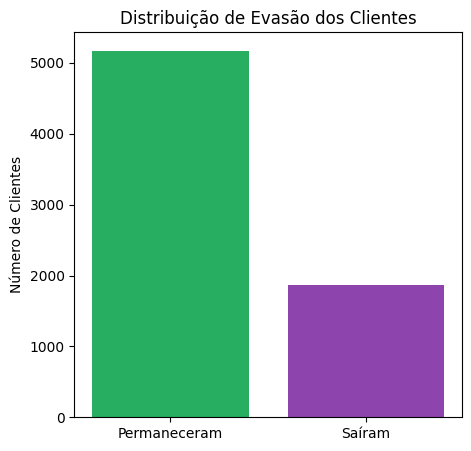

In [ ]:
import matplotlib.pyplot as plt

contagem_evasao = df['Evasao'].value_counts()

plt.figure(figsize=(5,5))
plt.bar(contagem_evasao.index, contagem_evasao.values, color=['#27ae60','#8e44ad'])
plt.xticks([0,1], ['Permaneceram', 'Saíram'])
plt.ylabel('Número de Clientes')
plt.title('Distribuição de Evasão dos Clientes')
plt.show()

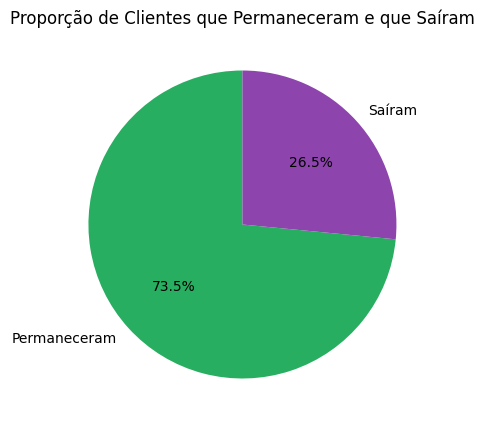

In [ ]:
plt.figure(figsize=(5,5))
plt.pie(contagem_evasao.values, labels=['Permaneceram', 'Saíram'], autopct='%1.1f%%', startangle=90, colors=['#27ae60','#8e44ad'])
plt.title('Proporção de Clientes que Permaneceram e que Saíram')
plt.show()

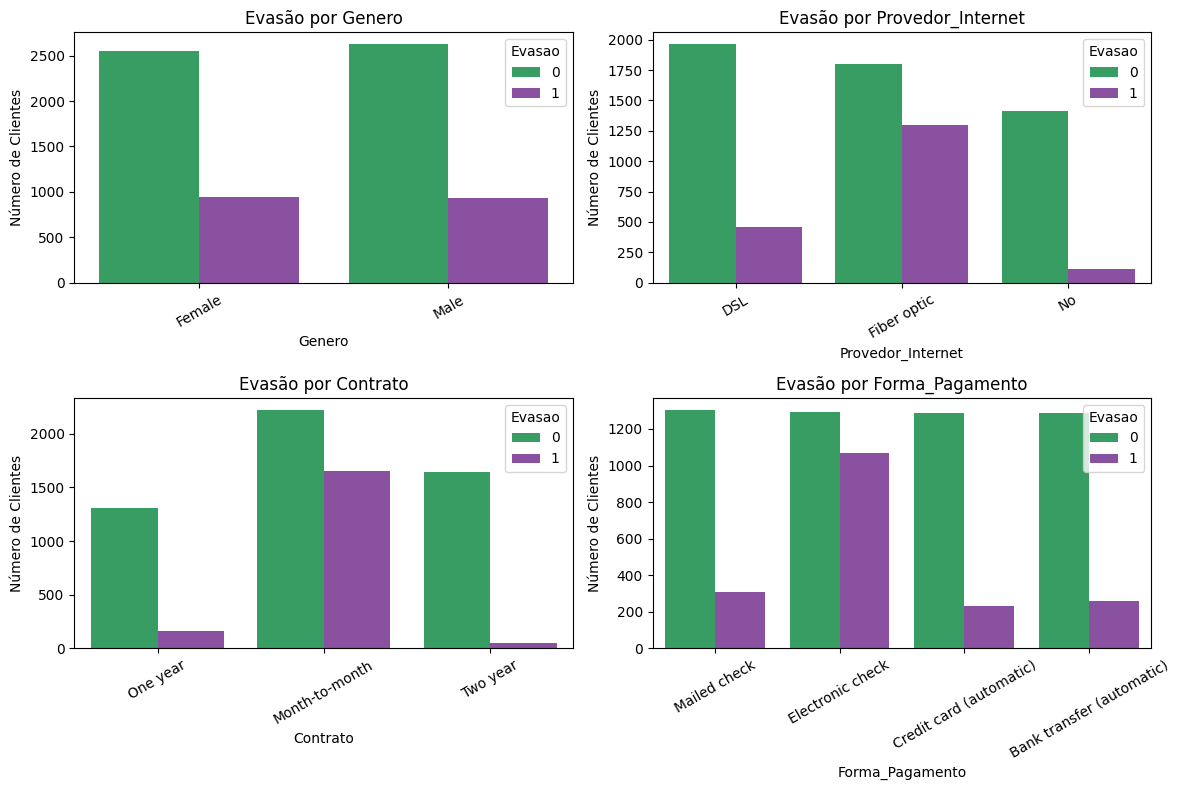

In [ ]:
import seaborn as sns

colunas_categoricas1 = ["Genero", "Provedor_Internet", "Contrato", "Forma_Pagamento"]
n_cols = 2
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas1):
    sns.countplot(
        x=col,
        hue="Evasao",
        data=df,
        palette=["#27ae60", "#8e44ad"],
        ax=axes[i]
    )
    axes[i].set_title(f"Evasão por {col}")
    axes[i].set_ylabel("Número de Clientes")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



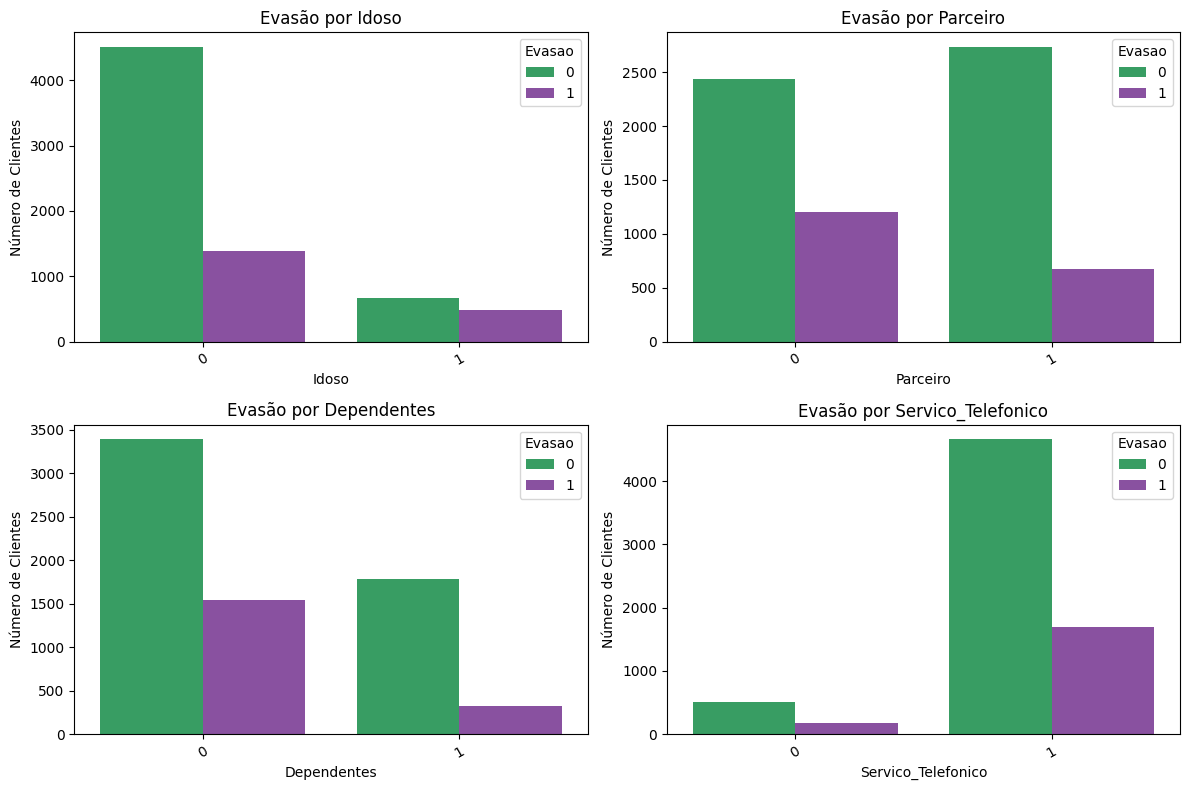

In [ ]:
colunas_categoricas2 = ["Idoso", "Parceiro", "Dependentes", "Servico_Telefonico"]
n_cols = 2
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas2):
    sns.countplot(
        x=col,
        hue="Evasao",
        data=df,
        palette=["#27ae60", "#8e44ad"],
        ax=axes[i]
    )
    axes[i].set_title(f"Evasão por {col}")
    axes[i].set_ylabel("Número de Clientes")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

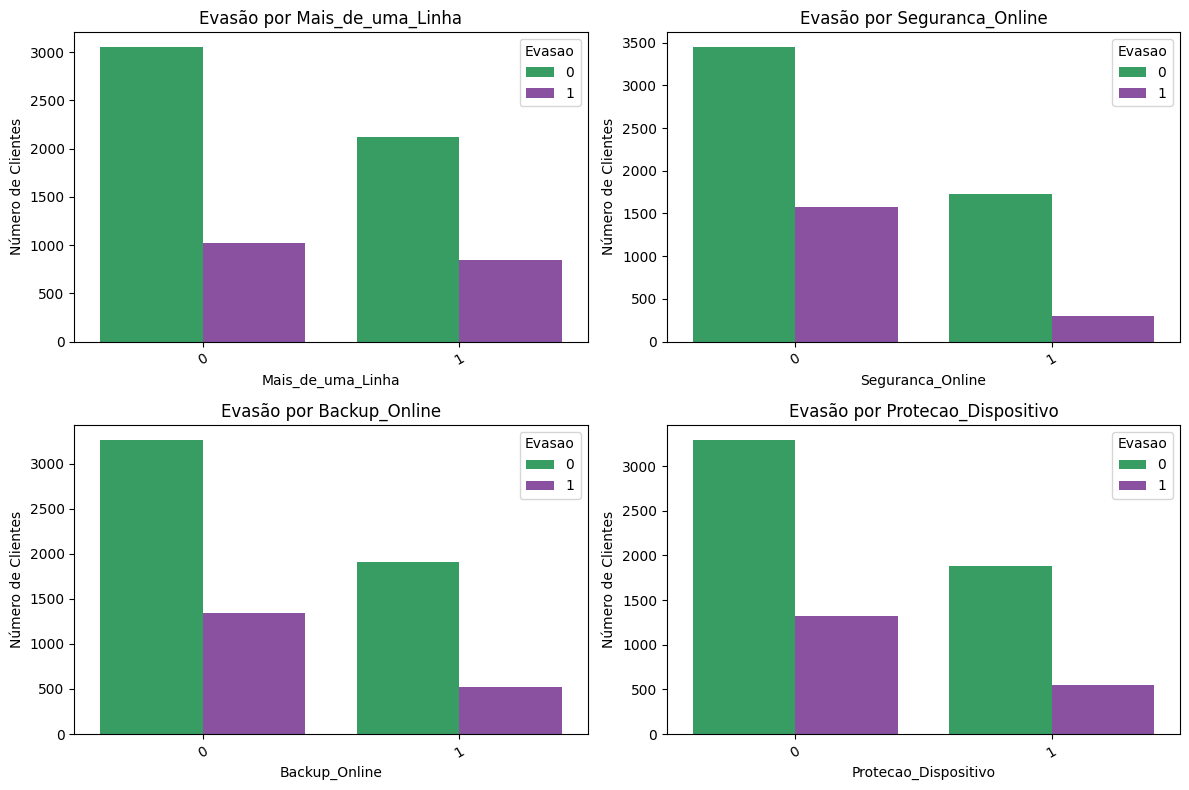

In [ ]:
colunas_categoricas3 = ["Mais_de_uma_Linha", "Seguranca_Online", "Backup_Online", "Protecao_Dispositivo"]
n_cols = 2
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas3):
    sns.countplot(
        x=col,
        hue="Evasao",
        data=df,
        palette=["#27ae60", "#8e44ad"],
        ax=axes[i]
    )
    axes[i].set_title(f"Evasão por {col}")
    axes[i].set_ylabel("Número de Clientes")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

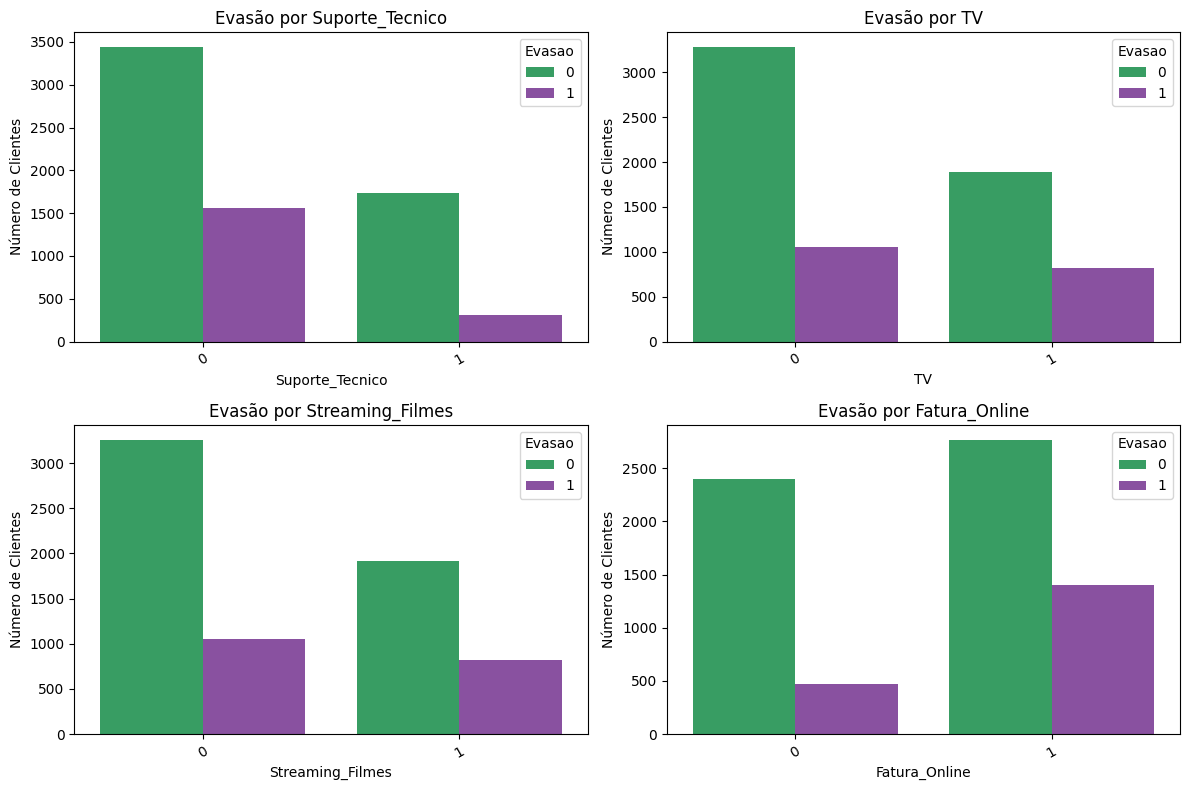

In [ ]:
colunas_categoricas4 = ["Suporte_Tecnico", "TV", "Streaming_Filmes", "Fatura_Online"]
n_cols = 2
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas4):
    sns.countplot(
        x=col,
        hue="Evasao",
        data=df,
        palette=["#27ae60", "#8e44ad"],
        ax=axes[i]
    )
    axes[i].set_title(f"Evasão por {col}")
    axes[i].set_ylabel("Número de Clientes")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
import math
import os

def plotar_numericas(df, colunas, n_cols=2, n_rows=2):
    """
    Gera boxplots de variáveis numéricas em blocos 2x2.
    Retorna lista de figuras (sem salvar).
    """
    figuras = []
    blocos = math.ceil(len(colunas) / (n_cols*n_rows))

    for b in range(blocos):
        subset = colunas[b*(n_cols*n_rows):(b+1)*(n_cols*n_rows)]

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
        axes = axes.flatten()

        for i, col in enumerate(subset):
            sns.boxplot(
                x="Evasao",
                y=col,
                hue="Evasao",   # para não dar warning
                data=df,
                palette=["#27ae60", "#8e44ad"],
                legend=False,
                ax=axes[i]
            )
            axes[i].set_title(f"Evasão vs {col}")
            axes[i].set_xlabel("Evasão (0 = permaneceu, 1 = saiu)")
            axes[i].set_ylabel(col)

        # remove gráficos vazios do último painel
        for j in range(len(subset), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        figuras.append(fig)

    return figuras


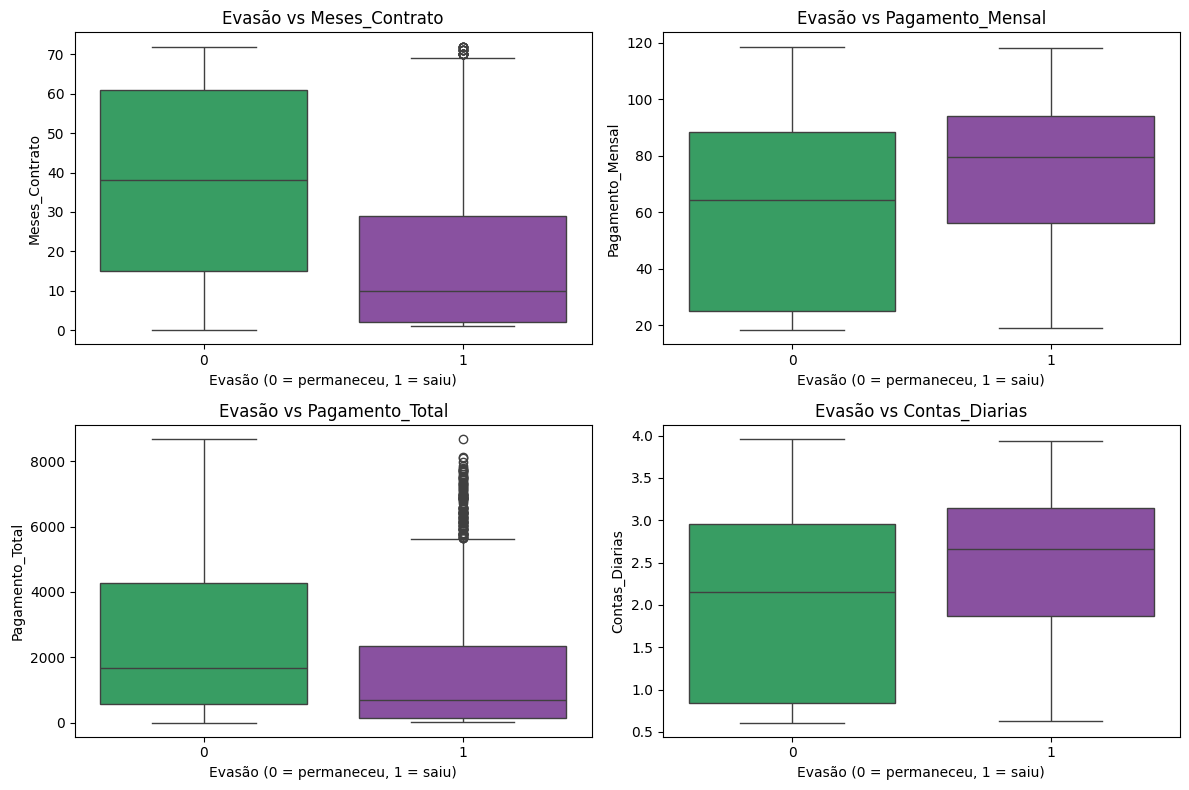

In [ ]:
colunas_numericas = [
    "Meses_Contrato", "Pagamento_Mensal", "Pagamento_Total", "Contas_Diarias"
]

# Gerar os gráficos
figs_num = plotar_numericas(df, colunas_numericas)

# Mostrar no notebook
for fig in figs_num:
    plt.show(fig)

fig.savefig('colunas_numericas.png', transparent=False, dpi=300, bbox_inches='tight')

#📄Relatorio Final

In [8]:
get_ipython().system('zip -r /content/TelecomX_BR.zip /content/TelecomX_BR.ipynb')

	zip warning: name not matched: /content/TelecomX_BR.ipynb

zip error: Nothing to do! (try: zip -r /content/TelecomX_BR.zip . -i /content/TelecomX_BR.ipynb)


In [9]:
from google.colab import files
files.download('/content/TelecomX_BR.zip')

FileNotFoundError: Cannot find file: /content/TelecomX_BR.zip

In [10]:
from google.colab import files
files.download('/content/TelecomX_BR.ipynb')

FileNotFoundError: Cannot find file: /content/TelecomX_BR.ipynb